In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Air Quality Prediction (UCI Dataset) - Time Series Regression
Algorithm       : Vanilla Recurrent Neural Network (RNN) – completely from scratch

Description     : Full manual implementation of a simple (Vanilla) RNN 
                  without using any high-level recurrent layers (nn.RNN, etc.).

                  Implemented components from scratch:
                  - Input-to-hidden and hidden-to-hidden weight matrices
                  - Forward propagation through time
                  - Backpropagation Through Time (BPTT)
                  - Softmax output for multi-class classification

                  Applied to the UCI Air Quality dataset for multi-step 
                  time series regression.

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


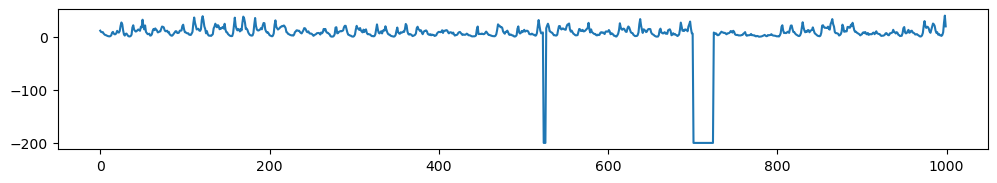

In [17]:
#%% load dataset 
filename= r'AirQualityUCI.xlsx'
df= pd.read_excel(filename)

# print(df.tail(5))
names= df.columns
target= df.iloc[:,5].to_numpy()
df= df.drop(names[5], axis=1)
data= df.iloc[:,2:].to_numpy()

data[np.isnan(data)]=0
target[np.isnan(target)]=0
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(target[:1000])
plt.show()

In [18]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=False)

In [19]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [20]:
def sequence_data(data,target,step):
    tau= step
    data_seq=[]
    target_seq= []
    for i in range(tau,data.shape[0],1):
        d= data[i-tau:i]
        y= target[i-tau:i]
        data_seq.append(d)
        target_seq.append(y)
        # print(i)
    data_seq = np.array(data_seq)
    target_seq = np.array(target_seq)
    return data_seq,target_seq

Xtrain_seq,y_train_seq= sequence_data(Xtrain,y_train,step=5)
Xtest_seq,y_test_seq= sequence_data(Xtest,y_test,step=5)
print(Xtrain_seq.shape,y_train_seq.shape)
print(Xtest_seq.shape,y_test_seq.shape)

(6544, 5, 12) (6544, 5)
(2803, 5, 12) (2803, 5)


In [21]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain_seq).type(torch.float32)
y_train= torch.from_numpy(y_train_seq).type(torch.float32)

Xtest= torch.from_numpy(Xtest_seq).type(torch.float32)
y_test= torch.from_numpy(y_test_seq).type(torch.float32)

In [22]:
def xavier_init(shape):
    fan_in, fan_out = shape[1], shape[0]
    # limit = torch.sqrt(torch.tensor(6.0 / (fan_in + fan_out)))
    # w= torch.empty(shape).uniform_(-limit, limit)
    sigma= torch.sqrt(torch.tensor(2 / (fan_in + fan_out)))
    w= torch.randn(shape)*sigma
    return w
def orthogonal_init(shape):
    # shape = (n_hidden, n_hidden)
    W = torch.randn(shape)
    q, r = torch.linalg.qr(W)
    # Ensure determinant is positive (for orthogonal)
    if torch.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q
class RNN():
     def __init__(self,n_features,n_hidden,n_out,lr=0.001,wrate=1):
          self.n_features= n_features
          self.n_hidden= n_hidden
          self.n_out= n_out
          self.lr=lr
          
          self.wx= xavier_init((n_hidden, n_features) )
          self.bx= torch.randn(n_hidden,1)*wrate
          
          self.whh= orthogonal_init((n_hidden,n_hidden))
          
          self.wo= xavier_init((n_out,n_hidden) )
          self.bo= torch.randn(n_out,1)*wrate
          
          
          self.dwx= torch.zeros_like(self.wx)
          self.dbx= torch.zeros_like(self.bx)
          self.dwhh= torch.zeros_like(self.whh)
          self.dwo= torch.zeros_like(self.wo)
          self.dbo= torch.zeros_like(self.bo) 

     def __call__(self,x,h0=None):
          yos,hts,hps= self.forward(x,h0)
          return yos,hts,hps
          
              
     def forward(self,x,h0=None):  
          wx,bx,whh,wo,bo= self.wx,self.bx,self.whh,self.wo,self.bo
          bath_size,T,_= x.size()# b_s x T x n_f (4,5,12)
          n_hidden,n_out= self.n_hidden,self.n_out
          
          if h0 == None:
               h_prev= torch.zeros(n_hidden,bath_size)
          else:
               h_prev= h0
          
          yos=[]
          hts=[]
          hps=[]
          
          for t in range(T):
               xt= x[:,t,:].T # (b_s x n_f).T = n_f x b_s
               vt= wx@xt + whh@h_prev + bx # n_hid x n_f,  n_f x b_s = n_hid*b_s
               ht= torch.tanh(vt) # n_hid*b_s
               
               yt= wo@ht + bo # n_o x n_hid x n_hid x b_s = n_o x b_s
               yos.append(yt)

               hts.append(ht)
               hps.append(h_prev)
               h_prev= ht # n_hid*b_s
               
          return yos,hts,hps
   
     def backward(self,x,y_true, y_pred,hts,hps):
          wx,bx,whh,wo,bo= self.wx,self.bx,self.whh,self.wo,self.bo
          bath_size,T,_= x.size()# b_s x T x n_f (4,5,12)
          n_hidden,n_out= self.n_hidden,self.n_out
          
          dh_next= torch.zeros(bath_size,n_hidden)
          for t in reversed(range(T)):
               xt= x[:,t,:] # b_s*n_f
               ht= hts[t].T# (n_hid*b_s).T= b_s x n_hid
               h_prev= hps[t].T# (n_hid*b_s).T= b_s x n_hid
               
               yot= y_pred[t]
               dt= y_true[:,t].T #  n_out x b_s 
               
               # et= dt-yot
               delta_o= dt-yot # n_o x b_s
               self.dwo+=delta_o@ ht# n_o x b_s x b_s x n_hid = n_o x n_hid
               self.dbo+= torch.sum(delta_o,dim=1,keepdim=True)

               dh_out= delta_o.T@ wo # b_s x n_o x n_o x n_hid = b_s x n_hid
               gdh= self.g_tanh(ht)# b_s x n_hid
               # dv=#
               dh= dh_out + dh_next # b_s x n_hid
               
               dv= (dh*gdh).T

               self.dwx+= dv@xt #n_hid x b_s x b_s*n_f = n_hid x n_f
               self.dbx+= torch.sum(dv,dim=1,keepdim=True)
               
               self.dwhh+= dv@h_prev # n_hid x b_s x b_s x n_hid
               
               dh_next= (dv.T@whh) #( n_hid x b_s).T= (b_s x n_hid )
          
          self.dwx/= (bath_size)
          self.dbx/= (bath_size)
          self.dwhh/= (bath_size)
          self.dwo/= (bath_size)
          self.dbo/= (bath_size)
               
     def step(self):
          self.wx+=self.lr*self.dwx
          self.bx+=self.lr*self.dbx
          self.whh+=self.lr*self.dwhh
          self.wo+=self.lr*self.dwo
          self.bo+=self.lr*self.dbo
     
     def zero_grad(self):
          self.dwx.zero_()
          self.dbx.zero_()
          self.dwhh.zero_()
          self.dwo.zero_()
          self.dbo.zero_() 
     
     def mse(self,y_true,y_pred):
          y_true= y_true.T
          e= y_true-y_pred
          return torch.mean(e**2)
     
     def g_tanh(self,y):
          return (1-y**2)
     
     def g_sigmoid(self,y):
          return y*(1-y)
     
     def g_relu(self,y):
          yhat= (y>0).type(torch.float32)
          return yhat
     
     def g_linear(self,y):
          return torch.ones(y.size())

In [23]:
#% build data loader 
ds= TensorDataset(Xtrain,y_train)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [24]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.001
n_out= 1
n_hid1= 85

n_features=Xtrain_seq.shape[2]
mdl = RNN(n_features, 
          n_hid1, n_out,
          lr=lr)

In [25]:
mse=[]
epoch=30
h0=None
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred,hts,hps= mdl(xbatch,h0)
          mdl.zero_grad()
          mdl.backward(xbatch,ybatch,ypred,hts,hps) 
          mdl.step()
          er.append(mdl.mse(ybatch[:,-1],ypred[-1])) 
          # print(er[i])
          h0= hts[-1]

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]:.8f}')

mse=torch.tensor(mse)


MSE(0): 276.10986328
MSE(1): 7.88359022
MSE(2): 3.07322574
MSE(3): 2.26995373
MSE(4): 1.95847750
MSE(5): 1.67468083
MSE(6): 1.57714856
MSE(7): 1.26140344
MSE(8): 1.20501530
MSE(9): 1.05307019
MSE(10): 0.97705376
MSE(11): 0.88705015
MSE(12): 0.82129961
MSE(13): 0.75933015
MSE(14): 0.70372152
MSE(15): 0.65409285
MSE(16): 0.60790157
MSE(17): 0.56550008
MSE(18): 0.52599281
MSE(19): 0.48954034
MSE(20): 0.45611450
MSE(21): 0.42581525
MSE(22): 0.39855400
MSE(23): 0.37403503
MSE(24): 0.35195425
MSE(25): 0.33216095
MSE(26): 0.31427231
MSE(27): 0.29783607
MSE(28): 0.28263336
MSE(29): 0.26854327


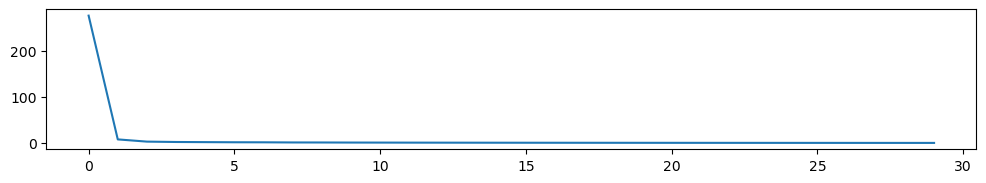

In [31]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [27]:
#%% test trained Neural Network
ypred=[]
h0=None
c0=None
for i in range(Xtest.size(0)):
    xt= Xtest[i]
    xt= xt.unsqueeze(0)
    # yp= mdl(xt)[0]
    ypred_list, hts,hps = mdl.forward(xt,h0)
    h0,c0=hts[-1],hps
    # yp= torch.argmax(yp.T,dim=1)
    ypred.append(ypred_list)

ypred= np.array(ypred)

In [28]:
ypred.shape

(2803, 5, 1, 1)

In [29]:
ypred=ypred.flatten()
d_test= y_test.flatten()

print(ypred.shape,d_test.shape,Xtest.shape,ypred[-1].shape,Xtest[i].shape)

(14015,) torch.Size([14015]) torch.Size([2803, 5, 12]) () torch.Size([5, 12])


MSE:0.399
MAE:0.425
R square:1.000


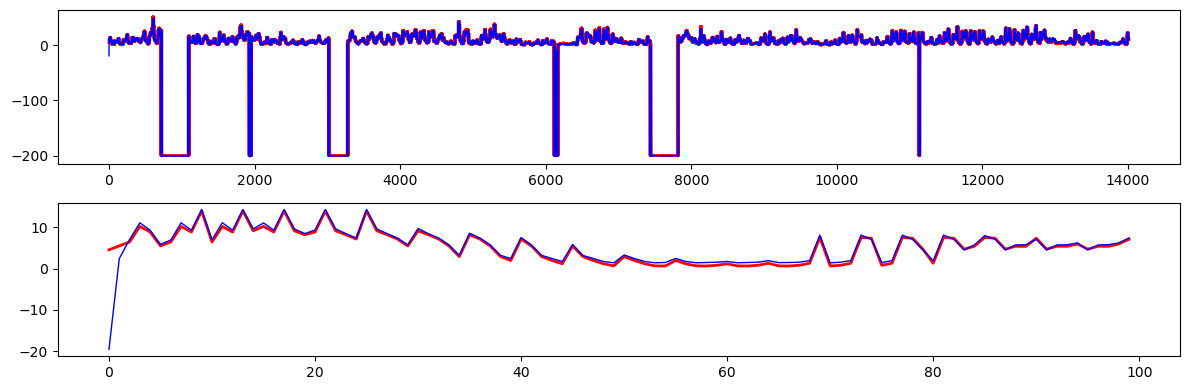

In [30]:
#%% validate your Neural Network
MSE= metrics.mean_squared_error(d_test,ypred)
MAE= metrics.mean_absolute_error(d_test,ypred)
r2= metrics.r2_score(d_test,ypred)

# input= torch.cat((d_test.reshape(1,-1),ypred.reshape(1,-1)),dim=0)
# cr= torch.corrcoef(input)
# corr= cr[0,1]
print(f'MSE:{MSE:.3f}')
print(f'MAE:{MAE:.3f}')
print(f'R square:{r2:.3f}')
# print(f'correlation:{corr:.3f}')

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(d_test,'r',linewidth=2)
plt.plot(ypred,'b',linewidth=1)
plt.subplot(2,1,2)
plt.plot(d_test[:100],'r',linewidth=2)
plt.plot(ypred[:100],'b',linewidth=1)
plt.tight_layout()
plt.show()